# OpenCap to NWB Pipeline Demo with Optional EMG

This notebook demonstrates a simple end-to-end software pipeline:

```text
test_data/subject0
   ├── MarkerData/Squats_0.trc
   ├── OpenSimData/IK/Squats_0.mot
   └── EMGData/Squats_0_synthetic_raw_emg.csv
          ↓
   opencap_to_nwb.convert_session()
          ↓
   test_output/subject0_squats_with_emg_demo.nwb
          ↓
   PyNWB inspection + simple plots
```

**The goal is to show that the converter can:**

1. Generate an NWB file from data in `test_data/subject0`.
2. Reopen the NWB file and verify that expected objects exist.
3. Demonstrate a **simple software pipeline** from input files to NWB inspection and plotting.

**Important: the included EMG fixture is synthetic. It is used for illustration purposes as there was no real EMG available during creation of this notebook.**


## 1. Setup

This cell finds the repository root whether the notebook is run from the repo root or from the `notebooks/` folder.


In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

# Find repository root robustly.
cwd = Path.cwd().resolve()

if (cwd / "pyproject.toml").exists():
    repo_root = cwd
elif (cwd.parent / "pyproject.toml").exists():
    repo_root = cwd.parent
else:
    raise RuntimeError(
        "Could not find repo root. Run this notebook from the repo root or notebooks/."
    )

src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from opencap_to_nwb.convert import convert_session

repo_root

PosixPath('/home/phil/Documents/code/opencap-to-nwb')

## 2. Define input and output paths

This demo uses the `Squats_0` trial from `test_data/subject0`.

Expected files:

- `MarkerData/Squats_0.trc`
- `OpenSimData/IK/Squats_0.mot`
- `EMGData/Squats_0_synthetic_raw_emg.csv`


In [13]:
subject_dir = repo_root / "test_data" / "subject0"
output_dir = repo_root / "test_output"
output_dir.mkdir(exist_ok=True)

trial = "Squats_0"

trc_path = subject_dir / "MarkerData" / f"{trial}.trc"
mot_path = subject_dir / "OpenSimData" / "IK" / f"{trial}.mot"
emg_path = subject_dir / "EMGData" / f"{trial}_synthetic_raw_emg.csv"

output_path = output_dir / "subject0_squats_with_emg_demo.nwb"

paths = {
    "subject_dir": subject_dir,
    "trc_path": trc_path,
    "mot_path": mot_path,
    "emg_path": emg_path,
    "output_path": output_path,
}

for name, path in paths.items():
    print(f"{name}: {path}")
    if name != "output_path":
        print("  exists:", path.exists())

subject_dir: /home/phil/Documents/code/opencap-to-nwb/test_data/subject0
  exists: True
trc_path: /home/phil/Documents/code/opencap-to-nwb/test_data/subject0/MarkerData/Squats_0.trc
  exists: True
mot_path: /home/phil/Documents/code/opencap-to-nwb/test_data/subject0/OpenSimData/IK/Squats_0.mot
  exists: True
emg_path: /home/phil/Documents/code/opencap-to-nwb/test_data/subject0/EMGData/Squats_0_synthetic_raw_emg.csv
  exists: True
output_path: /home/phil/Documents/code/opencap-to-nwb/test_output/subject0_squats_with_emg_demo.nwb


## 3. Check that required input files exist

For this notebook, the EMG file is expected to exist. This keeps the demo explicit and prevents accidentally running a non-EMG conversion while thinking EMG was included.


In [14]:
required_inputs = [subject_dir, trc_path, mot_path, emg_path]

missing = [path for path in required_inputs if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required demo input(s):\n" + "\n".join(str(path) for path in missing)
    )

print("All required demo inputs exist.")

All required demo inputs exist.


## 4. Generate the NWB file

This is the conversion step.

The EMG file is passed explicitly with `emg_path`. EMG timestamps are preserved from the CSV. The converter does not automatically synchronize, resample, or time-warp EMG data.


In [15]:
converted_path = convert_session(
    input_dir=subject_dir,
    output_path=output_path,
    trial=trial,
    emg_path=emg_path,
)

print("Wrote:", converted_path)
print("Exists:", converted_path.exists())
print(f"Size: {converted_path.stat().st_size / 1e6:.2f} MB")

Wrote: /home/phil/Documents/code/opencap-to-nwb/test_output/subject0_squats_with_emg_demo.nwb
Exists: True
Size: 2.92 MB


## 5. Reopen the NWB file and inspect the structure

This verifies that the NWB file is readable and contains the expected movement and EMG objects.


In [16]:
with NWBHDF5IO(str(output_path), "r") as io:
    nwb = io.read()

    print("Identifier:", nwb.identifier)
    print("Session ID:", nwb.session_id)
    print("Session description:", nwb.session_description)
    print("Subject ID:", nwb.subject.subject_id if nwb.subject else None)

    print("\nProcessing modules:")
    for name in nwb.processing:
        print(" -", name)

    print("\nAcquisition objects:")
    for name in nwb.acquisition:
        print(" -", name)

    behavior = nwb.processing["behavior"]
    print("\nBehavior data interfaces:")
    for name in behavior.data_interfaces:
        print(" -", name)

Identifier: subject0-subject0-Squats_0
Session ID: subject0
Session description: OpenCap/OpenSim-style movement outputs converted to NWB. V1 stores pose and joint angles as generic TimeSeries. Activity: squat.
Subject ID: subject0

Processing modules:
 - behavior

Acquisition objects:
 - RawEMG

Behavior data interfaces:
 - OpenCapJointAngles
 - OpenCapPose3D


## 6. Validate expected NWB objects

This cell performs basic software checks. It is not a full scientific validation. It verifies that:

- pose data exists
- joint-angle data exists
- raw EMG data exists
- all three have timestamps
- arrays are non-empty


In [17]:
with NWBHDF5IO(str(output_path), "r") as io:
    nwb = io.read()

    behavior = nwb.processing["behavior"]

    assert "OpenCapPose3D" in behavior.data_interfaces
    assert "OpenCapJointAngles" in behavior.data_interfaces
    assert "RawEMG" in nwb.acquisition

    pose = behavior["OpenCapPose3D"]
    joint = behavior["OpenCapJointAngles"]
    emg = nwb.acquisition["RawEMG"]

    assert pose.data.shape[0] > 0
    assert joint.data.shape[0] > 0
    assert emg.data.shape[0] > 0

    assert pose.timestamps is not None
    assert joint.timestamps is not None
    assert emg.timestamps is not None

    print("Pose shape:", pose.data.shape)
    print("Joint angle shape:", joint.data.shape)
    print("EMG shape:", emg.data.shape)

    print(
        "\nPose time range:",
        float(pose.timestamps[0]),
        "to",
        float(pose.timestamps[-1]),
    )
    print(
        "Joint time range:",
        float(joint.timestamps[0]),
        "to",
        float(joint.timestamps[-1]),
    )
    print("EMG time range:", float(emg.timestamps[0]), "to", float(emg.timestamps[-1]))

    print("\nBasic NWB content checks passed.")

Pose shape: (832, 189)
Joint angle shape: (832, 35)
EMG shape: (13851, 10)

Pose time range: 0.0 to 13.85
Joint time range: 0.0 to 13.85
EMG time range: 0.0 to 13.85

Basic NWB content checks passed.


## 7. Simple software pipeline output table

This compact summary shows the main data objects created by the pipeline.


In [18]:
with NWBHDF5IO(str(output_path), "r") as io:
    nwb = io.read()
    behavior = nwb.processing["behavior"]

    pose = behavior["OpenCapPose3D"]
    joint = behavior["OpenCapJointAngles"]
    emg = nwb.acquisition["RawEMG"]

    summary = [
        {
            "name": "OpenCapPose3D",
            "location": "processing/behavior",
            "shape": tuple(pose.data.shape),
            "unit": pose.unit,
            "time_start_s": float(pose.timestamps[0]),
            "time_end_s": float(pose.timestamps[-1]),
        },
        {
            "name": "OpenCapJointAngles",
            "location": "processing/behavior",
            "shape": tuple(joint.data.shape),
            "unit": joint.unit,
            "time_start_s": float(joint.timestamps[0]),
            "time_end_s": float(joint.timestamps[-1]),
        },
        {
            "name": "RawEMG",
            "location": "acquisition",
            "shape": tuple(emg.data.shape),
            "unit": emg.unit,
            "time_start_s": float(emg.timestamps[0]),
            "time_end_s": float(emg.timestamps[-1]),
        },
    ]

summary

[{'name': 'OpenCapPose3D',
  'location': 'processing/behavior',
  'shape': (832, 189),
  'unit': 'm',
  'time_start_s': 0.0,
  'time_end_s': 13.85},
 {'name': 'OpenCapJointAngles',
  'location': 'processing/behavior',
  'shape': (832, 35),
  'unit': 'mixed or unknown',
  'time_start_s': 0.0,
  'time_end_s': 13.85},
 {'name': 'RawEMG',
  'location': 'acquisition',
  'shape': (13851, 10),
  'unit': 'mV',
  'time_start_s': 0.0,
  'time_end_s': 13.85}]

## 8. Plot one joint-angle time series from NWB

This reads the converted NWB file and plots one joint-angle / coordinate column.


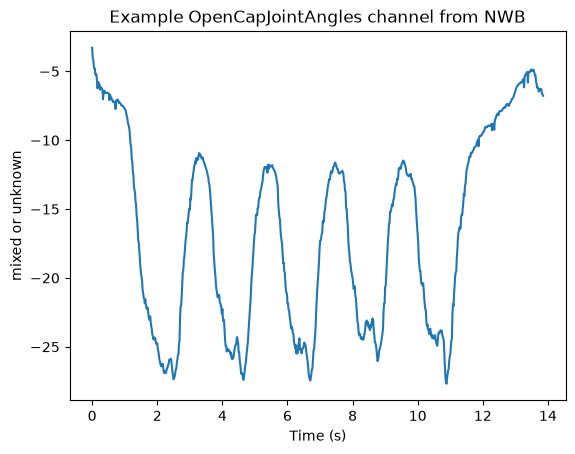

In [19]:
with NWBHDF5IO(str(output_path), "r") as io:
    nwb = io.read()
    joint = nwb.processing["behavior"]["OpenCapJointAngles"]

    joint_time = joint.timestamps[:]
    joint_data = joint.data[:]

plt.figure()
plt.plot(joint_time, joint_data[:, 0])
plt.xlabel("Time (s)")
plt.ylabel(joint.unit)
plt.title("Example OpenCapJointAngles channel from NWB")
plt.show()

## 9. Plot one pose coordinate from NWB

This reads the flattened marker/body-point position time series from the generated NWB file and plots the first coordinate column.


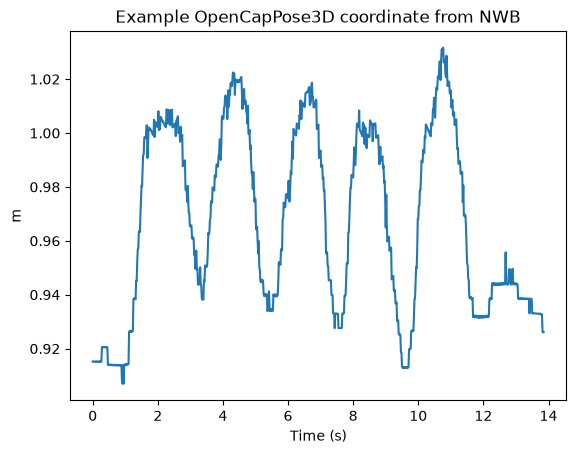

In [20]:
with NWBHDF5IO(str(output_path), "r") as io:
    nwb = io.read()
    pose = nwb.processing["behavior"]["OpenCapPose3D"]

    pose_time = pose.timestamps[:]
    pose_data = pose.data[:]

plt.figure()
plt.plot(pose_time, pose_data[:, 0])
plt.xlabel("Time (s)")
plt.ylabel(pose.unit)
plt.title("Example OpenCapPose3D coordinate from NWB")
plt.show()

## 10. Plot one raw EMG channel from NWB

This verifies that EMG was written into the NWB file and can be read back as an acquisition `TimeSeries`.


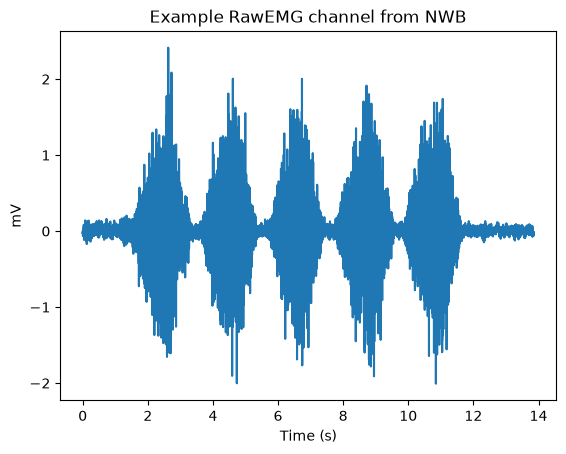

In [21]:
with NWBHDF5IO(str(output_path), "r") as io:
    nwb = io.read()
    emg = nwb.acquisition["RawEMG"]

    emg_time = emg.timestamps[:]
    emg_data = emg.data[:]

plt.figure()
plt.plot(emg_time, emg_data[:, 0])
plt.xlabel("Time (s)")
plt.ylabel(emg.unit)
plt.title("Example RawEMG channel from NWB")
plt.show()

## 11. Final check

At this point, the notebook has shown the full demo pipeline:

```text
TRC + MOT + optional EMG CSV
        ↓
convert_session()
        ↓
NWB file
        ↓
PyNWB readback
        ↓
shape checks + simple plots
```

This demonstrates that the converter works as a software pipeline. It does not claim that the synthetic EMG file is real biological data.
